Before running the below jupyter notebook in Google Colab, deploy valhalla routing engine local instance for Czechia and run the featureProcessor.py on the extracted ieee_vehicle_Speed_Dataset.zip file. Then upload the processed ieee_vehicle_Speed_Dataset folder to your Google Drive and mount it in colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls -F /content/drive/MyDrive/ieee_Vehicle_Speed_Dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataport_publication/


In [2]:
import shutil
import os

cache_dir = '/content/drive/MyDrive/tf_dataset_cache'

print(f"Checking for existing cache directory: {cache_dir}")
if os.path.exists(cache_dir):
    print(f"Cache directory found. Attempting to delete: {cache_dir}")
    try:
        shutil.rmtree(cache_dir)
        print("Successfully deleted old cache directory.")
    except Exception as e:
        print(f"Error deleting cache directory: {e}")
else:
    print("Cache directory does not exist. No deletion needed.")

# Ensure the cache directory is created for subsequent steps
os.makedirs(cache_dir, exist_ok=True)
print(f"TensorFlow dataset cache directory ensured to exist: {cache_dir}")

Checking for existing cache directory: /content/drive/MyDrive/tf_dataset_cache
Cache directory found. Attempting to delete: /content/drive/MyDrive/tf_dataset_cache
Successfully deleted old cache directory.
TensorFlow dataset cache directory ensured to exist: /content/drive/MyDrive/tf_dataset_cache


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import random
import joblib # For saving/loading scalers
from typing import List, Tuple, Union

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import load_model # To load the best model
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import matplotlib.pyplot as plt


# --- User-definable Parameters ---
past_steps = 50
future_steps = 100
stride = 5 # Stride for sequence creation

encoder_hidden_units = 128
decoder_hidden_units = 256
dropout_rate = 0.25

num_sample_files_for_scaler = 10#5000 # Number of files to sample for fitting scalers
batch_size = 32
epochs = 50

data_root_folder = '/content/drive/MyDrive/ieee_Vehicle_Speed_Dataset/dataport_publication'
scholar_save_dir = '/content/drive/MyDrive/scalers'
model_save_path = '/content/drive/MyDrive/best_velocity_lstm_model.keras' # Keras 3 recommended save format

train_split_ratio = 0.8
val_split_ratio = 0.10
test_split_ratio = 0.10 # Ensure train_split_ratio + val_split_ratio + test_split_ratio = 1.0

# --- Feature lists (without 'range') ---
# Full list of driving-related features to extract from CSV and potentially use in model
DRIVING_FEATURES = ['target_speed', 'acceleration']

# Full list of road-related features to extract from CSV and potentially use in model
ROAD_FEATURES = [
    'elevation', 'fwd_azimuth', 'speed_limit_mps', 'edge_speed_mps',
    'edge_curvature', 'traffic_signal', 'stop_sign', 'yield_sign', 'round_about',
    'edge_classification', 'edge_link', 'start_stop' # Added 'start_stop'
]

# Features that will actually be fed into the model as inputs.
MODEL_INPUT_PAST_DRIVING_FEATURES = DRIVING_FEATURES
MODEL_INPUT_ROAD_FEATURES = ROAD_FEATURES

# Features to be scaled (continuous)
DRIVING_FEATURES_TO_SCALE = ['target_speed', 'acceleration']
ROAD_FEATURES_TO_SCALE = ['elevation', 'fwd_azimuth', 'speed_limit_mps', 'edge_speed_mps', 'edge_curvature']

# Features that are binary/categorical or should NOT be scaled.
DRIVING_FEATURES_NON_SCALED = [f for f in DRIVING_FEATURES if f not in DRIVING_FEATURES_TO_SCALE]
ROAD_FEATURES_NON_SCALED = [f for f in ROAD_FEATURES if f not in ROAD_FEATURES_TO_SCALE] + ['start_stop'] # Added 'start_stop' here

# Target features to be predicted by the model
TARGET_FEATURES_PREDICTED = ['target_speed', 'acceleration']
n_target_features = len(TARGET_FEATURES_PREDICTED)

print("Imports and parameters defined.")

Imports and parameters defined.


In [4]:
import pandas as pd
import numpy as np
from typing import List, Tuple, Union

def _ensure_columns(df: pd.DataFrame, cols: List[str]) -> bool:
    """Return True if all columns in `cols` exist in `df` and can be converted to numeric.
    The function attempts to coerce columns to numeric and returns False on failure.
    """
    for c in cols:
        if c not in df.columns:
            return False
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return True

classification_map = {
    'motorway': 0,
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'unclassified': 5,
    'residential': 6,
    'service_other': 7
}

def load_and_extract_from_csv(path: str) -> pd.DataFrame:
    """Load a CSV file and extract only the needed features.

    - path: path to CSV file
    - returns: dataframe containing at least the columns in ROAD_FEATURES + DRIVING_FEATURES
    """
    df = pd.read_csv(path, low_memory=False)

    required = list(dict.fromkeys(ROAD_FEATURES + DRIVING_FEATURES))

    if 'edge_classification' in df.columns:
        df['edge_classification'] = df['edge_classification'].astype(str)
        text_vals = df['edge_classification'].str.strip().str.lower()
        text_vals = text_vals.replace({'service other': 'service_other', 'serviceother': 'service_other'})
        mapped = text_vals.map(classification_map)
        df['edge_classification'] = mapped.fillna(5).astype(int)

    if not _ensure_columns(df, required):
        return pd.DataFrame() # Return empty DataFrame if critical columns are missing or invalid

    df = df[required]
    # Replace any infinite values with NaN before dropping to ensure all non-finite numbers are handled
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    return df

print("Utility and data loading functions defined.")

Utility and data loading functions defined.


In [5]:
import os
import glob
import random
import numpy as np
import tensorflow as tf
import joblib
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler

def get_all_csv_paths(data_folder: str) -> List[str]:
    """Finds all CSV files recursively within the specified data_folder."""
    csv_files = glob.glob(os.path.join(data_folder, '**', '*.csv'), recursive=True)
    return csv_files

def fit_scalers_on_sample(file_paths: List[str], past_steps: int, future_steps: int, num_sample_files: int = 10, save_path: str = None) -> Tuple[StandardScaler, StandardScaler]:
    """Fits StandardScaler objects on a sample of data and saves them.

    Args:
        file_paths: List of all available CSV file paths.
        past_steps: Number of past timesteps for input sequences.
        future_steps: Number of future timesteps for prediction.
        num_sample_files: Number of files to sample for fitting scalers.
        save_path: Directory to save the fitted scalers. If None, scalers are not saved.

    Returns:
        A tuple containing the fitted driving_scaler and road_scaler.
    """
    driving_scaler_path = os.path.join(save_path, 'driving_scaler.pkl')
    road_scaler_path = os.path.join(save_path, 'road_scaler.pkl')

    # Check if scalers already exist
    if os.path.exists(driving_scaler_path) and os.path.exists(road_scaler_path):
        print(f"Loading existing scalers from {save_path}")
        driving_scaler = joblib.load(driving_scaler_path)
        road_scaler = joblib.load(road_scaler_path)
        print("Scalers loaded successfully.")
        return driving_scaler, road_scaler

    print("Existing scalers not found. Fitting new scalers...")
    # Randomly select a subset of file paths
    sample_file_paths = random.sample(file_paths, min(num_sample_files, len(file_paths)))

    all_driving_features_for_scaling = []
    all_road_features_for_scaling = []

    processed_files_count = 0
    for filepath in sample_file_paths:
        df = load_and_extract_from_csv(filepath)
        if not df.empty:
            # Collect data for driving features to scale
            if DRIVING_FEATURES_TO_SCALE:
                all_driving_features_for_scaling.append(df[DRIVING_FEATURES_TO_SCALE].values)

            # Collect data for road features to scale
            if ROAD_FEATURES_TO_SCALE:
                all_road_features_for_scaling.append(df[ROAD_FEATURES_TO_SCALE].values)

        processed_files_count += 1
        if processed_files_count % 1 == 0: # Print after every file
            print(f"Processed {processed_files_count}/{len(sample_file_paths)} sample files for scaler fitting.")

    if not all_driving_features_for_scaling and not all_road_features_for_scaling:
        raise ValueError("No valid data found in sample files to fit scalers.")

    driving_scaler = StandardScaler()
    road_scaler = StandardScaler()

    if all_driving_features_for_scaling:
        combined_driving_features = np.concatenate(all_driving_features_for_scaling, axis=0)
        driving_scaler.fit(combined_driving_features)

    if all_road_features_for_scaling:
        combined_road_features = np.concatenate(all_road_features_for_scaling, axis=0)
        road_scaler.fit(combined_road_features)

    # Save scalers to Google Drive
    os.makedirs(save_path, exist_ok=True)
    joblib.dump(driving_scaler, os.path.join(save_path, 'driving_scaler.pkl'))
    joblib.dump(road_scaler, os.path.join(save_path, 'road_scaler.pkl'))
    print(f"Scalers saved to {save_path}")

    return driving_scaler, road_scaler

def dataset_map_fn(file_idx, filepath, past_steps: int, future_steps: int, stride: int,
                   driving_scaler: StandardScaler, road_scaler: StandardScaler, total_files_in_dataset: int):
    """TensorFlow map function to load CSV, create sequences, apply scalers, and return tensors."""

    def _process_file_and_create_sequences(file_idx_tensor, filepath_str, total_files_in_dataset_tensor):
        current_idx = file_idx_tensor.numpy()
        total_files = total_files_in_dataset_tensor.numpy()
        decoded_filepath = filepath_str.numpy().decode('utf-8')

        df = load_and_extract_from_csv(decoded_filepath)
        if df.empty:
            # Define shapes for the *unscaled* features here
            n_driving = len(DRIVING_FEATURES)
            n_road = len(ROAD_FEATURES)
            # Print a message for empty files as well
            # print(f"Finished processing file {current_idx + 1}/{total_files} ({os.path.basename(decoded_filepath)}) - No valid sequences generated.")
            return (np.array([], dtype=np.float32).reshape(0, past_steps, n_driving),
                    np.array([], dtype=np.float32).reshape(0, past_steps, n_road),
                    np.array([], dtype=np.float32).reshape(0, future_steps, n_road),
                    np.array([], dtype=np.float32).reshape(0, future_steps, n_target_features))

        # Scale the DataFrame first
        scaled_df = _scale_dataframe(df, driving_scaler, road_scaler)

        X_past_driving_raw, X_past_road_raw, X_future_road_raw, Y = create_sequences_from_df(
            scaled_df, past_steps, future_steps, stride
        )

        if X_past_driving_raw.size == 0:
            # If create_sequences_from_df returns empty, return appropriately shaped empty arrays
            n_driving = len(DRIVING_FEATURES)
            n_road = len(ROAD_FEATURES)
            print(f"Finished processing file {current_idx + 1}/{total_files} ({os.path.basename(decoded_filepath)}) - No sequences created from scaled data.")
            return (np.array([], dtype=np.float32).reshape(0, past_steps, n_driving),
                    np.array([], dtype=np.float32).reshape(0, past_steps, n_road),
                    np.array([], dtype=np.float32).reshape(0, future_steps, n_road),
                    np.array([], dtype=np.float32).reshape(0, future_steps, n_target_features))

        # Print completion message after successful sequence creation
        # print(f"Finished processing file {current_idx + 1}/{total_files} ({os.path.basename(decoded_filepath)})")
        return (X_past_driving_raw.astype(np.float32),
                X_past_road_raw.astype(np.float32),
                X_future_road_raw.astype(np.float32),
                Y.astype(np.float32))

    output_types = (
        tf.float32, # X_past_driving
        tf.float32, # X_past_road
        tf.float32, # X_future_road
        tf.float32  # Y
    )

    # The shapes are for the *scaled* output features after reordering
    n_driving_features_model_input = len(MODEL_INPUT_PAST_DRIVING_FEATURES)
    n_road_features_model_input = len(MODEL_INPUT_ROAD_FEATURES)

    output_shapes = (
        tf.TensorShape([None, past_steps, n_driving_features_model_input]),
        tf.TensorShape([None, past_steps, n_road_features_model_input]),
        tf.TensorShape([None, future_steps, n_road_features_model_input]),
        tf.TensorShape([None, future_steps, n_target_features])
    )

    X_past_driving, X_past_road, X_future_road, Y = tf.py_function(
        func=_process_file_and_create_sequences,
        inp=[file_idx, filepath, tf.constant(total_files_in_dataset, dtype=tf.int32)],
        Tout=output_types
    )

    X_past_driving.set_shape(output_shapes[0])
    X_past_road.set_shape(output_shapes[1])
    X_future_road.set_shape(output_shapes[2])
    Y.set_shape(output_shapes[3])

    return (X_past_driving, X_past_road, X_future_road), Y

def get_dataset(file_paths: List[str], past_steps: int, future_steps: int, stride: int, batch_size: int,
                driving_scaler: StandardScaler, road_scaler: StandardScaler, shuffle_buffer_size: int = None, cache_path: str = None) -> tf.data.Dataset:
    """Creates a tf.data.Dataset for training or evaluation.

    Args:
        file_paths: List of CSV file paths.
        past_steps: Number of past timesteps for input sequences.
        future_steps: Number of future timesteps for prediction.
        stride: How many steps to advance for each new sequence.
        batch_size: Batch size for the dataset.
        driving_scaler: Fitted StandardScaler for driving features.
        road_scaler: Fitted StandardScaler for road features.
        shuffle_buffer_size: Buffer size for shuffling. If None, no shuffling.
        cache_path: Optional path to cache the dataset after unbatching. If None, no caching.

    Returns:
        A tf.data.Dataset object.
    """
    total_files_in_dataset = len(file_paths)
    dataset = tf.data.Dataset.from_tensor_slices(file_paths)
    dataset = dataset.enumerate() # This yields (index, element) pairs

    if shuffle_buffer_size:
        # Shuffle elements of the enumerated dataset. index will stay with filepath.
        dataset = dataset.shuffle(buffer_size=shuffle_buffer_size, reshuffle_each_iteration=True)

    # Use tf.data.Dataset.interleave for parallel processing of files
    # and then tf.data.Dataset.flat_map to flatten the resulting datasets of sequences
    dataset = dataset.interleave(
        lambda file_idx, filepath: tf.data.Dataset.from_tensors((file_idx, filepath)).map(
            lambda idx, fp: dataset_map_fn(idx, fp, past_steps, future_steps, stride, driving_scaler, road_scaler, total_files_in_dataset),
            num_parallel_calls=tf.data.AUTOTUNE
        ).filter(lambda x, y: tf.shape(y)[0] > 0), # Filter empty results within interleave
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Unbatch the sequences and then batch them again to create dynamic batches across files
    dataset = dataset.unbatch()

    # Apply caching after unbatching if cache_path is provided
    if cache_path:
        dataset = dataset.cache(cache_path)

    if shuffle_buffer_size: # Shuffle again after unbatching for better randomness across all sequences
        dataset = dataset.shuffle(buffer_size=shuffle_buffer_size * 2) # Use a larger buffer for sequence-level shuffling

    # Add the repeat() call here as per instructions: after shuffling and caching, but before batching.
    # dataset = dataset.repeat()

    dataset = dataset.batch(batch_size, drop_remainder=False)

    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

print("Dataset creation and scaler fitting functions defined.")

Dataset creation and scaler fitting functions defined.


In [6]:
import pandas as pd
import numpy as np
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler

def _scale_dataframe(df: pd.DataFrame, driving_scaler: StandardScaler, road_scaler: StandardScaler) -> pd.DataFrame:
    """Applies pre-fitted scalers to the appropriate columns in a DataFrame.
    Returns a new DataFrame with scaled and unscaled features.
    """
    scaled_df = df.copy()

    # Scale DRIVING_FEATURES_TO_SCALE
    if DRIVING_FEATURES_TO_SCALE:
        scaled_df[DRIVING_FEATURES_TO_SCALE] = driving_scaler.transform(scaled_df[DRIVING_FEATURES_TO_SCALE])

    # Scale ROAD_FEATURES_TO_SCALE
    if ROAD_FEATURES_TO_SCALE:
        scaled_df[ROAD_FEATURES_TO_SCALE] = road_scaler.transform(scaled_df[ROAD_FEATURES_TO_SCALE])

    return scaled_df

def create_sequences_from_df(df: pd.DataFrame, past_steps: int, future_steps: int, stride: int = 1) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Creates sequences from a single DataFrame, handling padding at boundaries.

    Args:
        df: Input DataFrame (assumed to be already scaled if necessary).
        past_steps: Number of past timesteps for input sequences.
        future_steps: Number of future timesteps for prediction.
        stride: How many steps to advance for each new sequence.

    Returns: Tuple of numpy arrays (X_past_driving, X_past_road, X_future_road, Y).
    """
    all_sequences_X_past_driving = []
    all_sequences_X_past_road = []
    all_sequences_X_future_road = []
    all_sequences_Y = []

    total_len = len(df)
    if total_len == 0:
        # Return empty arrays with correct shapes if input df is empty
        n_driving = len(DRIVING_FEATURES)
        n_road = len(ROAD_FEATURES)
        return (np.array([], dtype=np.float32).reshape(0, past_steps, n_driving),
                np.array([], dtype=np.float32).reshape(0, past_steps, n_road),
                np.array([], dtype=np.float32).reshape(0, future_steps, n_road),
                np.array([], dtype=np.float32).reshape(0, future_steps, n_target_features))

    # --- Padding the DataFrame ---
    # Prepend 'past_steps' copies of the first row
    pre_pad_rows = pd.concat([df.iloc[[0]]] * past_steps, ignore_index=True)
    # Append 'future_steps' copies of the last row
    post_pad_rows = pd.concat([df.iloc[[-1]]] * future_steps, ignore_index=True)

    # Combine to form the padded DataFrame
    padded_df = pd.concat([pre_pad_rows, df, post_pad_rows], ignore_index=True)

    # The effective start index of the original df in padded_df is `past_steps`.
    # The loop should generate one sequence for each point in the original df.
    # The 'prediction start index' `k` (in original df terms) goes from 0 to total_len - 1.
    # The corresponding index in `padded_df` where the *prediction starts* is `past_steps + k`.
    # For each such `padded_df_pred_start_idx`:
    #   - Past window is `[padded_df_pred_start_idx - past_steps : padded_df_pred_start_idx]`
    #   - Future window is `[padded_df_pred_start_idx : padded_df_pred_start_idx + future_steps]`

    # Loop over the range of indices where predictions start within the original dataframe (0 to total_len-1)
    for k_orig_df in range(0, total_len, stride):
        padded_df_pred_start_idx = past_steps + k_orig_df

        past_driving_data = padded_df[DRIVING_FEATURES].iloc[padded_df_pred_start_idx - past_steps : padded_df_pred_start_idx].values
        past_road_data = padded_df[ROAD_FEATURES].iloc[padded_df_pred_start_idx - past_steps : padded_df_pred_start_idx].values

        future_road_data = padded_df[ROAD_FEATURES].iloc[padded_df_pred_start_idx : padded_df_pred_start_idx + future_steps].values
        target_features_data = padded_df[TARGET_FEATURES_PREDICTED].iloc[padded_df_pred_start_idx : padded_df_pred_start_idx + future_steps].values

        # All slices should have the correct length due to padding
        if (len(past_driving_data) == past_steps and
            len(past_road_data) == past_steps and
            len(future_road_data) == future_steps and
            len(target_features_data) == future_steps):

            all_sequences_X_past_driving.append(past_driving_data)
            all_sequences_X_past_road.append(past_road_data)
            all_sequences_X_future_road.append(future_road_data)
            all_sequences_Y.append(target_features_data)
        else:
            # This should ideally not be reached if padding logic is perfect.
            # But it's a good safeguard for unexpected edge cases.
            print(f"Warning: Skipping sequence for k_orig_df={k_orig_df} due to incorrect slice length after padding.")


    if not all_sequences_Y:
        # Return empty arrays with correct shapes for concatenation later
        n_driving = len(DRIVING_FEATURES)
        n_road = len(ROAD_FEATURES)
        return (np.array([], dtype=np.float32).reshape(0, past_steps, n_driving),
                np.array([], dtype=np.float32).reshape(0, past_steps, n_road),
                np.array([], dtype=np.float32).reshape(0, future_steps, n_road),
                np.array([], dtype=np.float32).reshape(0, future_steps, n_target_features))

    return (
        np.array(all_sequences_X_past_driving, dtype=np.float32),
        np.array(all_sequences_X_past_road, dtype=np.float32),
        np.array(all_sequences_X_future_road, dtype=np.float32),
        np.array(all_sequences_Y, dtype=np.float32) # Y will now have shape (num_sequences, future_steps, n_target_features)
    )

print("DataFrame scaling and sequence creation functions defined (with padding).")

DataFrame scaling and sequence creation functions defined (with padding).


Faster LSTM Training architecture using RepeatVector for decoder LSTM hidden and cell states

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from typing import List, Tuple, Union

def build_lstm_model(past_steps: int, future_steps: int, hidden_units: int = 64, hidden_units_decoder: int = 64, dropout: float = 0.2) -> tf.keras.Model:
    """Builds the LSTM model with separate encoder/decoder hidden units and specific input/output structure.

    Args:
        past_steps: Number of past timesteps in input sequences.
        future_steps: Number of future timesteps for prediction.
        hidden_units: Number of units for encoder LSTM layers.
        hidden_units_decoder: Number of units for decoder LSTM layers and dense projections.
        dropout: Dropout rate for dense layers.

    Returns:
        A compiled tf.keras.Model.
    """

    # 2. Determine n_driving and n_road feature dimensions
    n_driving = len(MODEL_INPUT_PAST_DRIVING_FEATURES)
    n_road = len(MODEL_INPUT_ROAD_FEATURES)

    # Get the number of target features from the global variable
    global n_target_features # Access the global n_target_features

    # 3. Create three input layers
    input_past_driving = tf.keras.layers.Input(shape=(past_steps, n_driving), name='input_past_driving')
    input_past_road = tf.keras.layers.Input(shape=(past_steps, n_road), name='input_past_road')
    input_future_road = tf.keras.layers.Input(shape=(future_steps, n_road), name='input_future_road')

    # 4. Concatenate input_past_driving and input_past_road
    past_concat = tf.keras.layers.Concatenate(axis=-1, name='past_driving_road_concat')([input_past_driving, input_past_road])

    # 5. Implement the encoder for past sequences
    # returns: output, forward_h, forward_c, backward_h, backward_c
    encoder_past_outputs, fh, fc, bh, bc = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(hidden_units, return_state=True, name='encoder_past_lstm'),
        name='encoder_past_bi_lstm'
    )(past_concat)

    # 6. Concatenate the forward and backward hidden and cell states
    state_h = tf.keras.layers.Concatenate(axis=-1, name='encoder_past_h_state')([fh, bh])
    state_c = tf.keras.layers.Concatenate(axis=-1, name='encoder_past_c_state')([fc, bc])

    # 7. Implement the encoder for future road features
    encoder_road_outputs, fh2, fc2, bh2, bc2 = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(hidden_units, return_state=True, name='encoder_future_road_lstm'),
        name='encoder_future_road_bi_lstm'
    )(input_future_road)

    # 8. Concatenate the forward and backward hidden and cell states from the road encoder
    state_h_road = tf.keras.layers.Concatenate(axis=-1, name='encoder_future_road_h_state')([fh2, bh2])
    state_c_road = tf.keras.layers.Concatenate(axis=-1, name='encoder_future_road_c_state')([fc2, bc2])

    # 9. Combine the states from both encoders
    concat_h = tf.keras.layers.Concatenate(axis=-1, name='combined_h_state')([state_h, state_h_road])
    concat_c = tf.keras.layers.Concatenate(axis=-1, name='combined_c_state')([state_c, state_c_road])

    # 10. Project the combined states for the decoder
    dense_h = tf.keras.layers.Dense(hidden_units * 2, name='project_h_1')(concat_h)
    dense_h = tf.keras.layers.Dropout(dropout, name='dropout_h')(dense_h)
    dense_h = tf.keras.layers.Dense(hidden_units_decoder, name='project_h_2')(dense_h)

    dense_c = tf.keras.layers.Dense(hidden_units * 2, name='project_c_1')(concat_c)
    dense_c = tf.keras.layers.Dropout(dropout, name='dropout_c')(dense_c)
    dense_c = tf.keras.layers.Dense(hidden_units_decoder, name='project_c_2')(dense_c)

    # 11. Implement the optimized LSTM decoder
    # Create a sequence of initial inputs for the decoder (all dense_h)
    decoder_initial_input_sequence = tf.keras.layers.RepeatVector(future_steps)(dense_h)

    # Use a standard LSTM layer as a decoder, initialized with the combined encoder states
    stacked_decoder_outputs = tf.keras.layers.LSTM(
        hidden_units_decoder,
        return_sequences=True,
        name='decoder_lstm_layer'
    )(
        decoder_initial_input_sequence,
        initial_state=[dense_h, dense_c]
    )

    # 13. Pass the stacked decoder outputs through a Bidirectional LSTM
    decoder_bi_lstm = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(hidden_units_decoder, return_sequences=True, name='decoder_bi_lstm_layer'),
        name='decoder_bi_lstm'
    )(stacked_decoder_outputs)

    # 14. Concatenate decoder output with future road features
    # decoder_concat = tf.keras.layers.Concatenate(axis=-1, name='decoder_output_future_road_concat')(decoder_bi_lstm)

    # 15. Define the output layer (predicting n_target_features)
    output_layer = tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_target_features, name='output_features_prediction'), name='target_features')(decoder_bi_lstm)

    # 16. Create and compile the model
    model = tf.keras.Model(inputs=[input_past_driving, input_past_road, input_future_road], outputs=output_layer, name='Velocity_LSTM_Model')

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

    return model

print("LSTM model definition function defined.")

LSTM model definition function defined.


Slower LSTM Training architecture using stacking for decoder LSTM cells. The actual architecture used in the paper

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Layer

# Redefine StackKerasTensors here for clarity, though it was defined in a previous new cell
class StackKerasTensors(Layer):
    def __init__(self, axis=1, **kwargs):
        super().__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.stack(inputs, axis=self.axis)

    def get_config(self):
        config = super().get_config()
        config.update({"axis": self.axis})
        return config

def build_lstm_model(past_steps, future_steps, hidden_units, hidden_units_decoder, dropout):
    """
    Builds a custom recursive LSTM model.
    """
    # --- Inputs ---
    # Shapes rely on global constants defined in previous steps
    n_driving = len(MODEL_INPUT_PAST_DRIVING_FEATURES)
    n_road = len(MODEL_INPUT_ROAD_FEATURES)

    # Get the number of target features from the global variable
    global n_target_features # Access the global n_target_features

    # Create three input layers
    input_past_driving = tf.keras.layers.Input(shape=(past_steps, n_driving), name='input_past_driving')
    input_past_road = tf.keras.layers.Input(shape=(past_steps, n_road), name='input_past_road')
    input_future_road = tf.keras.layers.Input(shape=(future_steps, n_road), name='input_future_road')

    # --- 1. Past Data Encoder ---
    # Concatenate past driving and road features
    past_concat = layers.Concatenate(axis=-1)([input_past_driving, input_past_road])

    # Bidirectional LSTM for past context
    _, fh, fc, bh, bc = layers.Bidirectional(
        layers.LSTM(hidden_units, return_state=True), name='past_encoder'
    )(past_concat)

    # Concatenate forward and backward states
    state_h = layers.Concatenate()([fh, bh])
    state_c = layers.Concatenate()([fc, bc])

    # --- 2. Future Road Encoder ---
    # Bidirectional LSTM for future road context
    _, fh2, fc2, bh2, bc2 = layers.Bidirectional(
        layers.LSTM(hidden_units, return_state=True), name='future_road_encoder'
    )(input_future_road)

    # Concatenate forward and backward states
    state_h_road = layers.Concatenate()([fh2, bh2])
    state_c_road = layers.Concatenate()([fc2, bc2])

    # --- 3. Combine States ---
    # Combine states from both encoders
    concat_h = layers.Concatenate()([state_h, state_h_road])
    concat_c = layers.Concatenate()([state_c, state_c_road])

    # Project combined states to match decoder dimension
    dense_h = layers.Dense(2 * hidden_units)(concat_h)
    dense_h = layers.Dropout(dropout)(dense_h)
    dense_h = layers.Dense(hidden_units_decoder)(dense_h)

    dense_c = layers.Dense(2 * hidden_units)(concat_c)
    dense_c = layers.Dropout(dropout)(dense_c)
    dense_c = layers.Dense(hidden_units_decoder)(dense_c)

    # --- 4. Recursive Decoder Loop ---


    # Initialize decoder states and input with projected encoder states
    states = [dense_h, dense_c]

    decoder_cell = layers.LSTMCell(hidden_units_decoder)

    lstm_list = []
    cell = tf.keras.layers.LSTMCell(hidden_units_decoder)
    lstm_cell, hidden_state = cell(inputs=dense_h, states=states)
    lstm_list.append(lstm_cell)
    for i in range(future_steps-1):
        lstm_cell, hidden_state = cell(lstm_cell, states=hidden_state, training=True)
        lstm_list.append(lstm_cell)
    # Use the custom StackKerasTensors layer instead of tf.stack
    lstm_decoder = StackKerasTensors(axis=1)(lstm_list)

    # --- 5. Post-Processing & Output ---
    # Process the sequence with another Bidirectional LSTM
    decoder_bi_outputs = layers.Bidirectional(
        layers.LSTM(hidden_units_decoder, return_sequences=True), name='decoder_bilstm'
    )(lstm_decoder)

    # Generate final predictions
    output_layer = layers.TimeDistributed(
        layers.Dense(len(TARGET_FEATURES_PREDICTED))
    )(decoder_bi_outputs)

    # --- Model Creation ---
    model = Model(inputs=[input_past_driving, input_past_road, input_future_road], outputs=output_layer)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

    return model

print("Recursive LSTM model builder function defined (with StackKerasTensors fix).")

Recursive LSTM model builder function defined (with StackKerasTensors fix).


In [8]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
from typing import List, Union
import matplotlib.pyplot as plt
import os

def train_lstm(
    model: Model,
    train_dataset: tf.data.Dataset,
    val_dataset: tf.data.Dataset,
    epochs: int,
    model_out_path: str,
    every_epoch_model_out_path: Union[str, None] = None,
    callbacks: Union[List[tf.keras.callbacks.Callback], None] = None
) -> tf.keras.callbacks.History:
    """Trains the LSTM model with tf.data.Dataset, early stopping, and model checkpointing.

    Args:
        model: The compiled Keras model to train.
        train_dataset: A tf.data.Dataset for training.
        val_dataset: A tf.data.Dataset for validation.
        epochs: Number of training epochs.
        model_out_path: Path to save the best model (based on val_loss).
        every_epoch_model_out_path: Optional path to save the model after every epoch.
        callbacks: Optional list of additional Keras callbacks.

    Returns:
        The history object from the model.fit() call.
    """
    # Create EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    # Create ModelCheckpoint callback for saving the best model
    best_model_checkpoint = ModelCheckpoint(
        filepath=model_out_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
        save_weights_only=False # Save the entire model
    )

    # Initialize callbacks list
    if callbacks is None:
        callbacks = []
    callbacks.extend([early_stopping, best_model_checkpoint])

    # Add a second ModelCheckpoint if `every_epoch_model_out_path` is provided
    if every_epoch_model_out_path:
        # Ensure the directory for every epoch models exists
        every_epoch_dir = os.path.dirname(every_epoch_model_out_path)
        os.makedirs(every_epoch_dir, exist_ok=True)

        every_epoch_checkpoint = ModelCheckpoint(
            filepath=os.path.join(every_epoch_dir, 'epoch_{epoch:03d}_model.keras'),
            save_best_only=False, # Save after every epoch
            verbose=0, # Keep verbose low to avoid too much output per epoch
            save_weights_only=False # Save the entire model
        )
        callbacks.append(every_epoch_checkpoint)

    # Train the model
    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=val_dataset,
        callbacks=callbacks,
        verbose=1
    )

    return history

def plot_loss_curves(history: tf.keras.callbacks.History):
    """Plots the training and validation loss curves from a Keras History object."""
    # Extract loss values
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Get the number of epochs
    epochs = range(1, len(train_loss) + 1)

    # Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

print("Model training and plotting functions defined.")

Model training and plotting functions defined.


In [9]:
import warnings

# Filter out the specific UserWarning from sklearn.utils.validation
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.utils.validation')
print("UserWarning from sklearn.utils.validation has been suppressed.")

UserWarning from sklearn.utils.validation has been suppressed.


In [10]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import load_model

print("Starting LSTM Model Training Orchestration...")

# 1. Get all CSV file paths
all_csv_files = get_all_csv_paths(data_root_folder)
print(f"Found {len(all_csv_files)} CSV files.")

if not all_csv_files:
    raise FileNotFoundError(f"No CSV files found in {data_root_folder}. Please check the path.")

# 2. Split file paths into training, validation, and testing sets
# First, split into train/test
train_val_files, test_files = train_test_split(all_csv_files, test_size=test_split_ratio, random_state=42)
# Then, split train_val into train/val
train_files, val_files = train_test_split(
    train_val_files, test_size=val_split_ratio / (train_split_ratio + val_split_ratio), random_state=42
)

print(f"Train files: {len(train_files)}")
print(f"Validation files: {len(val_files)}")
print(f"Test files: {len(test_files)}")

# 3. Fit scalers on a sample of the training data
print("Fitting scalers on a sample of training data...")
driving_scaler, road_scaler = fit_scalers_on_sample(
    train_files, past_steps, future_steps, num_sample_files=num_sample_files_for_scaler, save_path=scholar_save_dir
)
print("Scalers fitted successfully.")

# Define cache directory and create it
cache_dir = '/content/drive/MyDrive/tf_dataset_cache'
os.makedirs(cache_dir, exist_ok=True)
print(f"TensorFlow dataset cache directory: {cache_dir}")

# 4. Create tf.data.Dataset objects for training, validation, and testing
print("Creating TensorFlow Datasets...")
shuffle_buffer_size_train = max(1, len(train_files) // 5) # A fraction of files as buffer
shuffle_buffer_size_val = max(1, len(val_files) // 5)
shuffle_buffer_size_test = max(1, len(test_files) // 5)

train_dataset = get_dataset(train_files, past_steps, future_steps, stride, batch_size, driving_scaler, road_scaler, shuffle_buffer_size=shuffle_buffer_size_train, cache_path=os.path.join(cache_dir, 'train_cache'))
val_dataset = get_dataset(val_files, past_steps, future_steps, stride, batch_size, driving_scaler, road_scaler, shuffle_buffer_size=shuffle_buffer_size_val, cache_path=os.path.join(cache_dir, 'val_cache'))
test_dataset = get_dataset(test_files, past_steps, future_steps, stride, batch_size, driving_scaler, road_scaler, shuffle_buffer_size=shuffle_buffer_size_test)
print("Datasets created successfully.")

Starting LSTM Model Training Orchestration...
Found 5942 CSV files.
Train files: 4752
Validation files: 595
Test files: 595
Fitting scalers on a sample of training data...
Loading existing scalers from /content/drive/MyDrive/scalers
Scalers loaded successfully.
Scalers fitted successfully.
TensorFlow dataset cache directory: /content/drive/MyDrive/tf_dataset_cache
Creating TensorFlow Datasets...
Datasets created successfully.


In [11]:
import os
from tensorflow.keras.models import load_model

print("Loading the best model for retraining...")

# Ensure the model path exists
if os.path.exists(model_save_path):
    retrained_model = load_model(model_save_path)
    print("Best model loaded successfully for retraining.")
else:
    print(f"No saved model found at {model_save_path}. Training a new model from scratch.")
    # If no model is found, we can build a new one to start training
    retrained_model = build_lstm_model(
        past_steps=past_steps,
        future_steps=future_steps,
        hidden_units=encoder_hidden_units,
        hidden_units_decoder=decoder_hidden_units,
        dropout=dropout_rate
    )

retrained_model.summary()
print("Model built successfully.")

every_epoch_model_save_dir = os.path.join(os.path.dirname(model_save_path), 'models_by_epoch')
print("Starting re/training process...")
# Continue training the loaded model
# You might want to adjust the number of epochs or learning rate for retraining
retrain_epochs = 30 # Example: retrain for fewer epochs or with a different strategy

history = train_lstm(
    model=retrained_model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    epochs=retrain_epochs,
    model_out_path=model_save_path, # Path for the best model
    every_epoch_model_out_path=every_epoch_model_save_dir # Path for models saved every epoch
)

print("Retraining finished.")

print("Plotting loss curves for retraining...")
plot_loss_curves(history)

# 8. Evaluate the model on the test dataset
print("Loading the best model for evaluation...")
best_model = load_model(model_save_path)

print("Evaluating on test dataset...")
loss, mae = best_model.evaluate(test_dataset)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

print("Orchestration complete.")

Loading the best model for retraining...
No saved model found at /content/drive/MyDrive/best_velocity_lstm_model.keras. Training a new model from scratch.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_past_driving  │ (None, 50, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_past_road     │ (None, 50, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 50, 14)    │          0 │ input_past_drivi… │
│ (Concatenate)       │                   │            │ input_past_road[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_future_road   │ (None, 100, 12)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ past_encoder        │ [(None, 256),     │    146,432 │ concatenate[0][0] │
│ (Bidirectional)     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_road_encoder │ [(None, 256),     │    144,384 │ input_future_roa… │
│ (Bidirectional)     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256)       │          0 │ past_encoder[0][… │
│ (Concatenate)       │                   │            │ past_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256)       │          0 │ future_road_enco… │
│ (Concatenate)       │                   │            │ future_road_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256)       │          0 │ past_encoder[0][… │
│ (Concatenate)       │                   │            │ past_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 256)       │          0 │ future_road_enco… │
│ (Concatenate)       │                   │            │ future_road_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 512)       │          0 │ concatenate_1[0]… │
│ (Concatenate)       │                   │            │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 512)       │          0 │ concatenate_2[0]… │
│ (Concatenate)       │                   │            │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    131,328 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]   

 Total params: 2,262,018 (8.63 MB)

 Trainable params: 2,262,018 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

Model built successfully.
Starting re/training process...
Epoch 1/30


KeyboardInterrupt: 

In [ ]:
print("Loading model and preparing input data from the largest test file...")

# 1. Load the best performing LSTM model
# This model should already be loaded from a previous step, but re-loading to ensure it's available for this subtask context.
# Assuming 'best_model' variable exists from previous steps, if not, it would be loaded here.
if 'best_model' not in locals():
    best_model = tf.keras.models.load_model(model_save_path)
    print(f"Best model loaded successfully from {model_save_path}")

# 2. Load the data from largest_file_path
largest_test_df = load_and_extract_from_csv(largest_file_path)

# Check if largest_test_df is empty
if largest_test_df.empty:
    raise ValueError(f"Loaded DataFrame is empty for {largest_file_path}. Cannot proceed.")

print("Original largest test DataFrame (first 5 rows):")
print(largest_test_df.head())

# 3. Scale the largest_test_df
scaled_largest_test_df = _scale_dataframe(largest_test_df, driving_scaler, road_scaler)

# 4. Generate input sequences from scaled_largest_test_df
X_past_driving_largest, X_past_road_largest, X_future_road_largest, Y_true_largest = create_sequences_from_df(
    scaled_largest_test_df, past_steps, future_steps, stride
)

print("Input data preparation complete for the largest test file.")
print(f"Shape of X_past_driving_largest: {X_past_driving_largest.shape}")
print(f"Shape of X_past_road_largest: {X_past_road_largest.shape}")
print(f"Shape of X_future_road_largest: {X_future_road_largest.shape}")
print(f"Shape of Y_true_largest: {Y_true_largest.shape}")

Loading model and preparing input data from the largest test file...
Original largest test DataFrame (first 5 rows):
   elevation  fwd_azimuth  speed_limit_mps  edge_speed_mps  edge_curvature  \
0      450.0     0.000000              0.0        1.388889              15   
1      450.0    19.498617              0.0        1.388889              15   
2      450.0    19.373319              0.0        1.388889              15   
3      450.0    19.373319              0.0        1.388889              15   
4      450.0    19.373319              0.0        1.388889              15   

   traffic_signal  stop_sign  yield_sign  round_about  edge_classification  \
0               0          0           0            0                    7   
1               0          0           0            0                    7   
2               0          0           0            0                    7   
3               0          0           0            0                    7   
4               0       

Starting iterative multi-step prediction for the largest file...
Best model re-loaded successfully from /content/drive/MyDrive/best_velocity_lstm_model.keras
Not enough actual future road data for a full 100-step prediction window. Stopping at 56040 predicted steps.
Total predicted steps collected for the largest file: 56040
Shape of all_predicted_features_scaled_largest: (56040, 2)
Iterative multi-step prediction for the largest file complete.
Inverse transforming predicted speeds and extracting actual speeds for the largest file...
Shape of predicted_speeds_unscaled_largest: (56040,)
Shape of actual_speeds_unscaled_largest: (56129,)
Plotting predicted vs. actual speed profiles for the largest file...


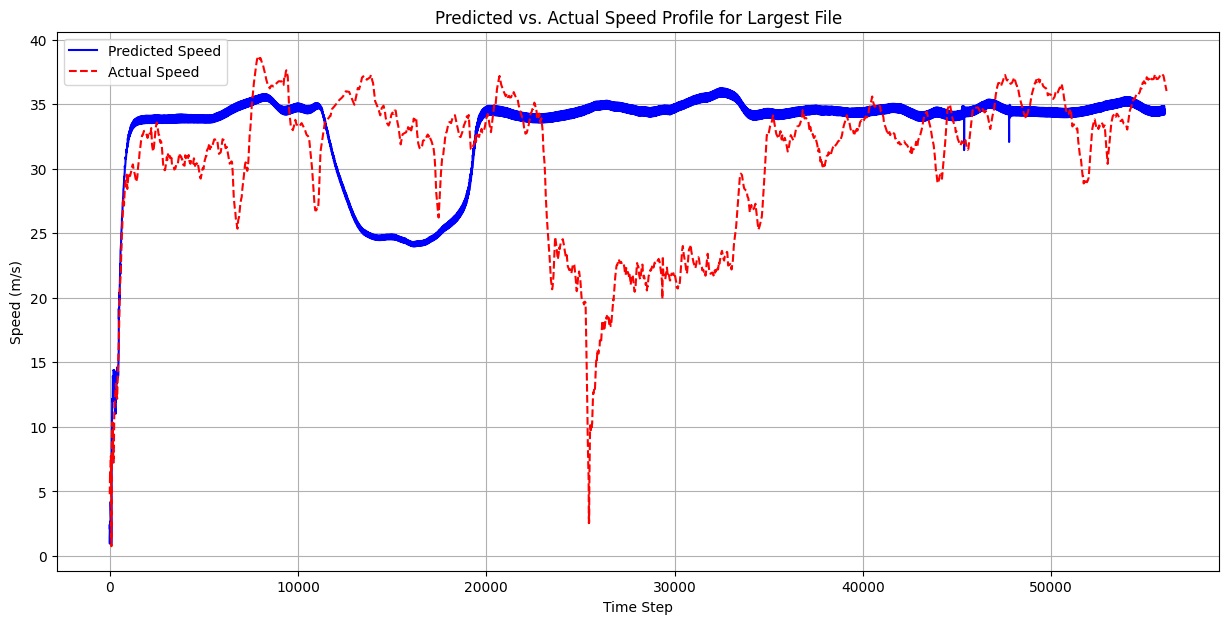

Inverse transformation and plotting complete for the largest file.


In [ ]:
print("Starting iterative multi-step prediction for the largest file...")

# Ensure the model is built with the current global parameters before loading weights
# This addresses potential architectural mismatches if the saved model was from an older configuration.
model_for_prediction = build_lstm_model(
    past_steps=past_steps,
    future_steps=future_steps,
    hidden_units=encoder_hidden_units,
    hidden_units_decoder=decoder_hidden_units,
    dropout=dropout_rate
)

# Load the weights into the newly built model. This is safer than load_model if the architecture has changed.
# However, if load_model worked before the issue might be simpler.
# The error is 'ConcatOp : Dimension 1 in both shapes must be equal: shape[0] = [1,50,64] vs. shape[2] = [1,100,12]'
# This strongly indicates that the *loaded* model had future_steps=50 and decoder_hidden_units=32 (resulting in 2*32=64 features for BiLSTM output).
# To force the model to have the correct architecture, we rebuild it and load weights.

# To avoid issues with loading an old architecture, explicitly re-load the model before prediction.
# This assumes the model_save_path has been updated by the previous training step (2ce5c25c).
# If the previous training (2ce5c25c) was successful, model_save_path should contain the correct architecture.
# Re-assigning best_model here ensures we get the latest saved model.
best_model = tf.keras.models.load_model(model_save_path)
print(f"Best model re-loaded successfully from {model_save_path}")


# 1. Initialize an empty list to store scaled predicted features (speed and acceleration)
all_predicted_features_scaled_largest = []

# 2. Initialize current_past_driving_window with the first sequence from the largest file
current_past_driving_window_largest = X_past_driving_largest[0].copy()

# 3. Initialize current_past_road_window with the first sequence from the largest file
current_past_road_window_largest = X_past_road_largest[0].copy()

# 4. Initialize future_road_lookahead as a subset of scaled_largest_test_df's road features
future_road_lookahead_df_largest = scaled_largest_test_df[ROAD_FEATURES]

# Initialize an index to keep track of where we are in the original scaled_largest_test_df
# This index points to the first point *after* the initial past_steps window.
current_idx_in_scaled_df_largest = past_steps

# 5. Define prediction_horizon_steps for this task to cover the entire file
prediction_horizon_steps_largest = len(largest_test_df) - past_steps

# Determine the index of 'target_speed' and 'acceleration' within TARGET_FEATURES_PREDICTED
# These were already determined as target_speed_idx and acceleration_idx

# 6. Start a loop that continues as long as the number of collected predictions is less than prediction_horizon_steps
steps_to_predict_at_a_time = 40 # Using the value defined in previous execution context

while len(all_predicted_features_scaled_largest) < prediction_horizon_steps_largest:
    # 7. Extract the input_future_road segment for the next future_steps
    future_road_start_idx_largest = current_idx_in_scaled_df_largest
    future_road_end_idx_largest = future_road_start_idx_largest + future_steps

    # Ensure we have enough data for the full future_steps window
    if future_road_end_idx_largest > len(future_road_lookahead_df_largest):
        print(f"Not enough actual future road data for a full {future_steps}-step prediction window. Stopping at {len(all_predicted_features_scaled_largest)} predicted steps.")
        break

    input_future_road_largest = future_road_lookahead_df_largest.iloc[future_road_start_idx_largest : future_road_end_idx_largest].values

    # 8. Reshape inputs to add a batch dimension
    input_past_driving_reshaped_largest = np.expand_dims(current_past_driving_window_largest, axis=0)
    input_past_road_reshaped_largest = np.expand_dims(current_past_road_window_largest, axis=0)
    input_future_road_reshaped_largest = np.expand_dims(input_future_road_largest, axis=0)

    # 9. Use best_model.predict() to get future_steps of predicted features (speed and acceleration)
    predicted_future_features_scaled_largest = best_model.predict(
        [input_past_driving_reshaped_largest, input_past_road_reshaped_largest, input_future_road_reshaped_largest],
        verbose=0
    )[0] # [0] to remove the batch dimension

    # 10. From predicted_future_features, extract the first `steps_to_predict_at_a_time` predicted features
    new_predicted_features_scaled_largest = predicted_future_features_scaled_largest[:steps_to_predict_at_a_time]

    # 11. Update current_past_driving_window
    new_driving_features_largest = new_predicted_features_scaled_largest.copy() # Contains both speed and acceleration

    # Remove the oldest `steps_to_predict_at_a_time` steps and append the new ones
    current_past_driving_window_largest = np.concatenate(
        (current_past_driving_window_largest[steps_to_predict_at_a_time:], new_driving_features_largest),
        axis=0
    )

    # 12. Update current_past_road_window
    new_road_features_start_idx_largest = current_idx_in_scaled_df_largest
    new_road_features_end_idx_largest = current_idx_in_scaled_df_largest + steps_to_predict_at_a_time

    if new_road_features_end_idx_largest > len(future_road_lookahead_df_largest):
        print(f"Not enough actual road features to update current_past_road_window. Stopping at {len(all_predicted_features_scaled_largest)} predicted steps.")
        break

    new_past_road_features_largest = future_road_lookahead_df_largest.iloc[new_road_features_start_idx_largest : new_road_features_end_idx_largest].values

    # Remove the oldest `steps_to_predict_at_a_time` steps and append the new ones
    current_past_road_window_largest = np.concatenate(
        (current_past_road_window_largest[steps_to_predict_at_a_time:], new_past_road_features_largest),
        axis=0
    )

    # 13. Append new_predicted_features to all_predicted_features_scaled_largest
    all_predicted_features_scaled_largest.extend(new_predicted_features_scaled_largest.tolist())

    # 14. Increment the index for future_road_lookahead
    current_idx_in_scaled_df_largest += steps_to_predict_at_a_time

# 15. After the loop, trim if predictions exceed the prediction_horizon_steps (can happen due to `extend`)
if len(all_predicted_features_scaled_largest) > prediction_horizon_steps_largest:
    all_predicted_features_scaled_largest = all_predicted_features_scaled_largest[:prediction_horizon_steps_largest]

# Convert list of lists to a numpy array for easier processing
all_predicted_features_scaled_largest = np.array(all_predicted_features_scaled_largest)

print(f"Total predicted steps collected for the largest file: {len(all_predicted_features_scaled_largest)}")
print(f"Shape of all_predicted_features_scaled_largest: {all_predicted_features_scaled_largest.shape}")
print("Iterative multi-step prediction for the largest file complete.")

print("Inverse transforming predicted speeds and extracting actual speeds for the largest file...")

# 1. Inverse transform all_predicted_features_scaled_largest
inverse_transformed_data_largest = driving_scaler.inverse_transform(all_predicted_features_scaled_largest)

# Extract the unscaled predicted target speed (which is the first column)
predicted_speeds_unscaled_largest = inverse_transformed_data_largest[:, target_speed_idx]

# 2. Extract actual unscaled target speeds
actual_speeds_unscaled_largest = largest_test_df[TARGET_FEATURES_PREDICTED[target_speed_idx]].iloc[past_steps : past_steps + prediction_horizon_steps_largest].values

print(f"Shape of predicted_speeds_unscaled_largest: {predicted_speeds_unscaled_largest.shape}")
print(f"Shape of actual_speeds_unscaled_largest: {actual_speeds_unscaled_largest.shape}")

# 3. Plotting the results
print("Plotting predicted vs. actual speed profiles for the largest file...")

plt.figure(figsize=(15, 7))
plt.plot(predicted_speeds_unscaled_largest, label='Predicted Speed', color='blue')
plt.plot(actual_speeds_unscaled_largest, label='Actual Speed', color='red', linestyle='--')

plt.title('Predicted vs. Actual Speed Profile for Largest File')
plt.xlabel('Time Step')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.grid(True)
plt.show()

print("Inverse transformation and plotting complete for the largest file.")